# Predicting Insurance Claim Severity for Decision Support

**Data Science Practicum Project**

## Research Question

> **Can machine learning predict insurance claim severity from day-one claim data accurately enough to improve reserve setting and adjuster routing?**

This notebook uses the Allstate Claims Severity dataset to evaluate three related questions:

1. Can a model predict final claim loss more accurately than simple baselines?
2. Can predicted severity help prioritize claims for reserve review and triage?
3. Do the available data justify automatic reserve amounts or adjuster assignments?

The project treats model output as a potential **decision-support signal**, not as an automatic claims decision. The analysis therefore evaluates average predictive accuracy, severe-claim performance, ranking quality, calibration, and operational review capacity.


## Analysis Roadmap

The notebook follows a reproducible applied-data-science workflow:

1. Define the business decisions and the limits of the research question.
2. Verify the supplied datasets and complete data-quality checks.
3. Explore the target distribution and feature structure.
4. Create a fixed training-validation split and establish simple baselines.
5. Compare two leakage-controlled preprocessing strategies with the same regression model.
6. Test retransformation bias, severe-claim error, ranking quality, and review-capacity performance.
7. Train the selected model on the full training dataset and produce test predictions.
8. Summarize what the evidence supports, what it does not support, and the most important next validation step.

### Key Terms

| Term | Meaning in this notebook |
|---|---|
| **Claim severity** | The final dollar loss associated with a claim |
| **Validation data** | Claims held out from model fitting and used for comparison |
| **Baseline** | A simple constant prediction that a useful model should beat |
| **MAE** | Mean absolute error, reported in dollars |
| **Underprediction** | Actual loss is greater than predicted loss |
| **Reserve review** | Human review of whether the current reserve is appropriate |
| **Review capacity** | The percentage of claims an operational team can examine |


## 1. Business Problem and Decision Scope

The research question combines several decisions that require different evidence:

- **Claim-severity prediction** estimates final loss in dollars.
- **Reserve-review prioritization** identifies claims that should be examined earlier.
- **Automatic reserve setting** uses a model prediction as the reserve amount without independent judgment.
- **Claim triage** identifies claims that may require earlier attention.
- **Adjuster routing** assigns a claim to a particular adjuster based on fit, skills, workload, and case needs.

The dataset supports an evaluation of loss prediction and financial-risk ranking. It does not contain adjuster skills, workloads, assignment histories, reserve histories, policy limits, injury details, litigation indicators, fraud indicators, or claim-handling outcomes.

Accordingly, this notebook can test whether predicted severity is useful for **prioritization**. It cannot establish that the model selects the correct reserve amount or the correct adjuster.


## 2. Data Sources and Reproducibility

The analysis uses the three supplied Allstate competition files:

| Dataset | Role in the analysis |
|---|---|
| Training CSV | Model development and holdout validation; includes `loss` |
| Test CSV | Final out-of-sample predictions; does not include `loss` |
| Sample-submission CSV | Required test IDs and output structure |

The loading code accepts the original filenames or renamed copies, but it requires each file to match the expected SHA-256 fingerprint. This prevents an older or different CSV from being used accidentally.

The final run uses all **188,318 training claims**. No synthetic observations or reduced demonstration sample are used.


In [1]:
%matplotlib inline

from pathlib import Path
import hashlib
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Show complete result tables instead of hiding important columns.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 100)

FAST_MODE = False
FAST_N = 30_000
BOOTSTRAP_SAMPLES = 500
SMEARING_CALIBRATION_FRACTION = 0.20
REVIEW_CAPACITIES = (0.05, 0.10, 0.20, 0.30)

_data_dir_env = os.getenv("ALLSTATE_DATA_DIR", "").strip()
DATA_DIR = Path(_data_dir_env).expanduser() if _data_dir_env else None

_output_dir_env = os.getenv("ALLSTATE_OUTPUT_DIR", "").strip()
OUTPUT_DIR = (
    Path(_output_dir_env).expanduser()
    if _output_dir_env
    else Path.cwd()
)
OUTPUT_FILENAME = "Allstate_Claim_Severity_Predictions.csv"

print(f"FAST_MODE: {FAST_MODE}")
print("Synthetic data used: False")
print(f"Random seed: {RANDOM_STATE}")
print("Data directory:", DATA_DIR if DATA_DIR else "automatic search")


FAST_MODE: False
Synthetic data used: False
Random seed: 42
Data directory: automatic search


In [2]:
EXPECTED_DATASETS = {
    "training": {
        "filename": "train(7).csv",
        "sha256": "74037cb248a1064e4d578692a4f4e5d8492ed1b2033daf643496e1b68b14ae03",
        "patterns": ["train(7).csv", "train.csv", "train*.csv"],
    },
    "test": {
        "filename": "test(7).csv",
        "sha256": "e8055e8cff1690046750e2098b95e3309a73e20501c45719c7eb591d87ab1052",
        "patterns": ["test(7).csv", "test.csv", "test*.csv"],
    },
    "sample submission": {
        "filename": "sample_submission(7).csv",
        "sha256": "3516c4397e647142d4581e8f6327340ceb5a4330a4e4737780603ba1b12d3b05",
        "patterns": [
            "sample_submission(7).csv",
            "sample_submission.csv",
            "sample_submission*.csv",
        ],
    },
}


def unique_existing_directories(paths):
    """Return unique existing directories while preserving order."""
    result = []
    seen = set()

    for path in paths:
        if path is None:
            continue

        path = Path(path).expanduser()
        try:
            key = str(path.resolve())
        except OSError:
            key = str(path)

        if key not in seen and path.exists() and path.is_dir():
            seen.add(key)
            result.append(path)

    return result


def sha256_file(path, chunk_size=1024 * 1024):
    """Return the SHA-256 digest of a file without loading it into memory."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def schema_matches(path, file_role):
    """Check whether a CSV candidate has the expected Allstate structure."""
    try:
        preview = pd.read_csv(path, nrows=5)
    except Exception:
        return False

    columns = set(preview.columns)
    feature_count = sum(
        column.startswith("cat") or column.startswith("cont")
        for column in preview.columns
    )

    if file_role == "training":
        return {"id", "loss"}.issubset(columns) and feature_count >= 50
    if file_role == "test":
        return "id" in columns and "loss" not in columns and feature_count >= 50
    if file_role == "sample submission":
        return {"id", "loss"}.issubset(columns) and len(preview.columns) <= 3

    raise ValueError(f"Unknown file role: {file_role}")


def candidate_directories(data_dir=DATA_DIR):
    """Return direct and recursive locations used to locate the provided CSVs."""
    cwd = Path.cwd()
    home = Path.home()

    direct = unique_existing_directories(
        [
            data_dir,
            cwd,
            cwd / "data",
            cwd / "input",
            cwd / "datasets",
            cwd.parent / "data",
            home / "Downloads",
            Path("/mnt/data"),
            Path("/content"),
            Path("/kaggle/input"),
        ]
    )

    recursive = unique_existing_directories(
        [
            data_dir,
            cwd if cwd not in {home, Path(cwd.anchor)} else None,
            cwd / "data",
            cwd / "input",
            cwd / "datasets",
            Path("/mnt/data"),
            Path("/content"),
            Path("/kaggle/input"),
        ]
    )
    return direct, recursive


def find_verified_csv(file_role, specification, data_dir=DATA_DIR):
    """Locate a CSV and require an exact fingerprint match to the provided file."""
    direct_dirs, recursive_dirs = candidate_directories(data_dir)
    expected_name = specification["filename"]
    expected_hash = specification["sha256"]

    candidates = []

    # Prefer the exact supplied filename.
    for directory in direct_dirs:
        candidates.append(directory / expected_name)
    for directory in recursive_dirs:
        if directory != Path(directory.anchor):
            candidates.extend(directory.rglob(expected_name))

    # Permit a renamed copy only when its bytes match the supplied dataset.
    for directory in direct_dirs:
        for pattern in specification["patterns"]:
            candidates.extend(directory.glob(pattern))
    for directory in recursive_dirs:
        if directory == Path(directory.anchor):
            continue
        for pattern in specification["patterns"]:
            candidates.extend(directory.rglob(pattern))

    unique_candidates = []
    seen = set()
    for path in candidates:
        if not path.is_file() or path.suffix.lower() != ".csv":
            continue
        try:
            key = str(path.resolve())
        except OSError:
            key = str(path)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(path)

    fingerprint_mismatches = []
    for path in unique_candidates:
        if not schema_matches(path, file_role):
            continue
        observed_hash = sha256_file(path)
        if observed_hash == expected_hash:
            print(f"Verified {file_role} dataset: {path.name}")
            return path, observed_hash
        fingerprint_mismatches.append((path.name, observed_hash))

    searched = "\n - ".join(str(path) for path in direct_dirs)
    mismatch_text = "\n".join(
        f" - {name}: {digest}" for name, digest in fingerprint_mismatches[:10]
    )
    raise FileNotFoundError(
        f"Could not locate the exact provided {file_role} dataset.\n\n"
        f"Expected file: {expected_name}\n"
        f"Expected SHA-256: {expected_hash}\n\n"
        f"Searched:\n - {searched}\n\n"
        f"Schema-compatible files with different fingerprints:\n"
        f"{mismatch_text or ' - none'}\n\n"
        "Place the supplied CSV beside the notebook or set ALLSTATE_DATA_DIR."
    )


train_path, train_sha256 = find_verified_csv(
    "training", EXPECTED_DATASETS["training"]
)
test_path, test_sha256 = find_verified_csv(
    "test", EXPECTED_DATASETS["test"]
)
submission_path, submission_sha256 = find_verified_csv(
    "sample submission", EXPECTED_DATASETS["sample submission"]
)

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_submission = pd.read_csv(submission_path)

source_verification = pd.DataFrame(
    [
        {
            "role": "training",
            "selected_file": train_path.name,
            "sha256": train_sha256,
            "rows": len(train_df),
            "columns": train_df.shape[1],
        },
        {
            "role": "test",
            "selected_file": test_path.name,
            "sha256": test_sha256,
            "rows": len(test_df),
            "columns": test_df.shape[1],
        },
        {
            "role": "sample submission",
            "selected_file": submission_path.name,
            "sha256": submission_sha256,
            "rows": len(sample_submission),
            "columns": sample_submission.shape[1],
        },
    ]
)

display(source_verification)


Verified training dataset: train.csv
Verified test dataset: test.csv
Verified sample submission dataset: sample_submission.csv


,role,selected_file,sha256,rows,columns
0,training,train.csv,74037cb248a1064e4d578692a4f4e5d8492ed1b2033daf643496e1b68b14ae03,188318,132
1,test,test.csv,e8055e8cff1690046750e2098b95e3309a73e20501c45719c7eb591d87ab1052,125546,131
2,sample submission,sample_submission.csv,3516c4397e647142d4581e8f6327340ceb5a4330a4e4737780603ba1b12d3b05,125546,2


## 3. Data Quality and Leakage Safeguards

Before modeling, the notebook verifies:

- required columns and aligned training-test schemas;
- missing values, blank strings, and infinite numeric values;
- duplicate rows and duplicate claim IDs;
- separation of training and test IDs;
- alignment between test IDs and sample-submission IDs; and
- exclusion of `loss` and `id` from model features.

Preprocessing is fitted only on the training portion of the data. Validation rows remain separate from model fitting, target-encoding mappings, and the Duan-smearing calibration sample.

These checks address direct target leakage, preprocessing leakage, validation leakage, and test leakage that can be detected from the available files. They cannot eliminate **semantic day-one leakage** because the feature meanings and timestamps are anonymized.


In [3]:
TARGET = "loss"
ID_COL = "id"

required_train_columns = {ID_COL, TARGET}
required_test_columns = {ID_COL}
required_submission_columns = {ID_COL, TARGET}

for dataset_name, frame, required_columns in [
    ("training", train_df, required_train_columns),
    ("test", test_df, required_test_columns),
    ("sample submission", sample_submission, required_submission_columns),
]:
    missing_columns = required_columns - set(frame.columns)
    if missing_columns:
        raise ValueError(
            f"{dataset_name.title()} data are missing required columns: "
            f"{sorted(missing_columns)}"
        )

categorical_cols = [
    column for column in train_df.columns if column.startswith("cat")
]
continuous_cols = [
    column for column in train_df.columns if column.startswith("cont")
]
feature_cols = categorical_cols + continuous_cols

if not feature_cols:
    raise ValueError("No feature columns beginning with 'cat' or 'cont' were found.")

assert TARGET not in feature_cols, "The target cannot appear in model features."
assert ID_COL not in feature_cols, "The ID cannot appear in model features."

train_feature_columns = set(train_df.columns) - {TARGET}
test_feature_columns = set(test_df.columns)

if train_feature_columns != test_feature_columns:
    raise ValueError(
        "Training and test feature schemas do not match. "
        f"Only in training: {sorted(train_feature_columns - test_feature_columns)[:10]}; "
        f"only in test: {sorted(test_feature_columns - train_feature_columns)[:10]}"
    )

train_df[TARGET] = pd.to_numeric(train_df[TARGET], errors="raise")
if (train_df[TARGET] < 0).any():
    raise ValueError("The loss target must be nonnegative.")

if len(sample_submission) != len(test_df):
    raise ValueError("The test data and sample submission have different row counts.")

if not sample_submission[ID_COL].reset_index(drop=True).equals(
    test_df[ID_COL].reset_index(drop=True)
):
    raise ValueError("Sample-submission IDs are not aligned with test IDs.")


def count_blank_strings(frame):
    """Count empty or whitespace-only values in string-like columns."""
    string_columns = frame.select_dtypes(include=["object", "string"]).columns
    if len(string_columns) == 0:
        return 0

    return int(
        frame[string_columns]
        .apply(lambda column: column.astype("string").str.strip().eq("").sum())
        .sum()
    )


def count_infinite_numeric_values(frame):
    """Count positive and negative infinity in numeric columns."""
    numeric_frame = frame.select_dtypes(include=np.number)
    return int(np.isinf(numeric_frame.to_numpy(dtype=float)).sum())


quality_summary = pd.DataFrame(
    {
        "dataset": ["training", "test"],
        "rows": [len(train_df), len(test_df)],
        "columns": [train_df.shape[1], test_df.shape[1]],
        "missing_values": [
            int(train_df.isna().sum().sum()),
            int(test_df.isna().sum().sum()),
        ],
        "blank_strings": [
            count_blank_strings(train_df),
            count_blank_strings(test_df),
        ],
        "infinite_numeric_values": [
            count_infinite_numeric_values(train_df),
            count_infinite_numeric_values(test_df),
        ],
        "duplicate_rows": [
            int(train_df.duplicated().sum()),
            int(test_df.duplicated().sum()),
        ],
        "duplicate_ids": [
            int(train_df[ID_COL].duplicated().sum()),
            int(test_df[ID_COL].duplicated().sum()),
        ],
    }
)

display(quality_summary)

zero_required = [
    "missing_values",
    "blank_strings",
    "infinite_numeric_values",
    "duplicate_rows",
    "duplicate_ids",
]
if (quality_summary[zero_required].to_numpy() != 0).any():
    raise AssertionError("The data-quality gate failed. Review the table above.")

if sample_submission[ID_COL].duplicated().any():
    raise AssertionError("Sample-submission IDs must be unique.")

overlapping_ids = set(train_df[ID_COL]).intersection(test_df[ID_COL])
if overlapping_ids:
    raise AssertionError("Training and test IDs unexpectedly overlap.")

print("Data-quality gate passed.")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Continuous features: {len(continuous_cols)}")
print(f"Total model features: {len(feature_cols)}")
print("Training/test feature alignment: passed")
print("Training/test ID overlap: none")

,dataset,rows,columns,missing_values,blank_strings,infinite_numeric_values,duplicate_rows,duplicate_ids
0,training,188318,132,0,0,0,0,0
1,test,125546,131,0,0,0,0,0


Data-quality gate passed.
Categorical features: 116
Continuous features: 14
Total model features: 130
Training/test feature alignment: passed
Training/test ID overlap: none


### Data-Quality Findings

Both the training and test files passed the executable quality checks:

- no missing, blank, or infinite values;
- no duplicate rows or claim IDs;
- matching feature schemas;
- no overlap between training and test claim IDs; and
- complete alignment between the test and sample-submission IDs.

The files are syntactically suitable for modeling. This does not prove that every anonymized predictor would be available when a real claim is first reported.


## 4. Dataset Scope and Limitations

### What the Dataset Can Support

The data can be used to test whether the available anonymized claim features:

- predict final claim loss better than simple baselines;
- rank higher-loss claims above lower-loss claims; and
- concentrate severe claims within a limited review queue.

### What the Dataset Cannot Establish

The analysis cannot independently verify:

- that every predictor is available on day one;
- performance on a later time period;
- improvement in actual reserve decisions;
- suitability for a specific adjuster;
- fairness or disparate impact across protected groups; or
- financial benefit in a live claims operation.

The results should therefore be interpreted as a holdout-based predictive study, not as evidence of deployment readiness.


## 5. Exploratory Data Analysis

The exploratory analysis focuses on the characteristics that directly affect model design:

1. the shape and skewness of final claim loss;
2. the scale and distribution of continuous predictors; and
3. the number and cardinality of categorical predictors.

This keeps the exploration tied to preprocessing, target transformation, and model evaluation.


,loss
count,188318.000000
mean,3037.337686
std,2904.086186
min,0.670000
1%,389.736800
5%,617.037000
10%,774.587000
25%,1204.460000
50%,2115.570000
75%,3864.045000


Loss skewness: 3.795


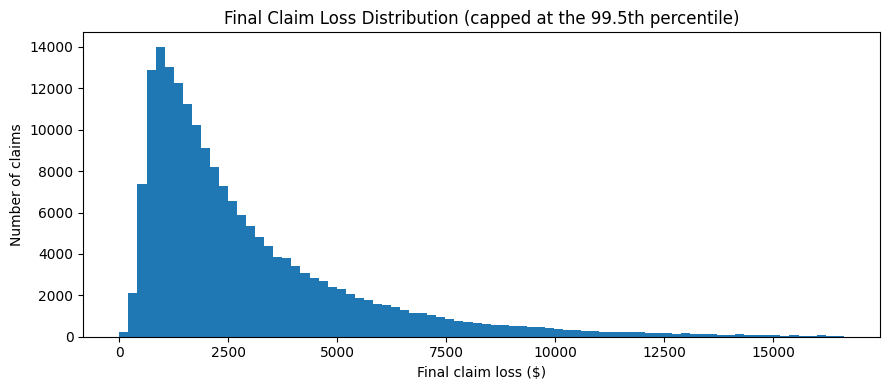

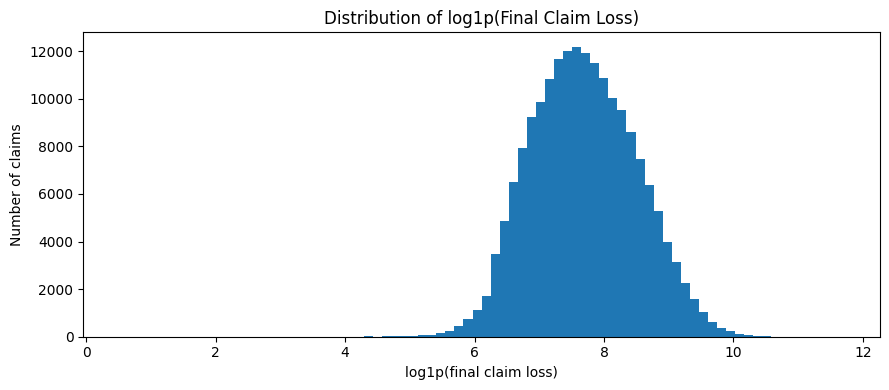

In [4]:
loss_summary = train_df[TARGET].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame("loss")
display(loss_summary)

print(f"Loss skewness: {train_df[TARGET].skew():.3f}")

plot_cap = train_df[TARGET].quantile(0.995)

plt.figure(figsize=(9, 4))
plt.hist(
    train_df.loc[train_df[TARGET] <= plot_cap, TARGET],
    bins=80,
)
plt.title("Final Claim Loss Distribution (capped at the 99.5th percentile)")
plt.xlabel("Final claim loss ($)")
plt.ylabel("Number of claims")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(np.log1p(train_df[TARGET]), bins=80)
plt.title("Distribution of log1p(Final Claim Loss)")
plt.xlabel("log1p(final claim loss)")
plt.ylabel("Number of claims")
plt.tight_layout()
plt.show()

### Claim-Loss Distribution and Modeling Implication

Final claim loss is strongly right-skewed: most claims are moderate, while a small number are extremely expensive. A model fitted directly to raw dollars can be dominated by those extreme observations.

The regression models therefore learn `log1p(loss)` and convert predictions back to dollars with `expm1`. This transformation can improve stability, but the inverse transformation does not automatically recover an unbiased conditional mean on the original dollar scale. Section 10 tests that retransformation issue explicitly.


,count,mean,std,min,25%,50%,75%,max,skewness
cont1,188318.0,0.493861,0.187640,0.000016,0.346090,0.475784,0.623912,0.984975,0.516424
cont2,188318.0,0.507188,0.207202,0.001149,0.358319,0.555782,0.681761,0.862654,-0.310941
cont3,188318.0,0.498918,0.202105,0.002634,0.336963,0.527991,0.634224,0.944251,-0.010002
cont4,188318.0,0.491812,0.211292,0.176921,0.327354,0.452887,0.652072,0.954297,0.416096
cont5,188318.0,0.487428,0.209027,0.281143,0.281143,0.422268,0.643315,0.983674,0.681622
cont6,188318.0,0.490945,0.205273,0.012683,0.336105,0.440945,0.655021,0.997162,0.461214
cont7,188318.0,0.484970,0.178450,0.069503,0.350175,0.438285,0.591045,1.000000,0.826053
cont8,188318.0,0.486437,0.199370,0.236880,0.312800,0.441060,0.623580,0.980200,0.676634
cont9,188318.0,0.485506,0.181660,0.000080,0.358970,0.441450,0.566820,0.995400,1.072429
cont10,188318.0,0.498066,0.185877,0.000000,0.364580,0.461190,0.614590,0.994980,0.355001


,unique_levels
cat116,326
cat110,131
cat109,84
cat113,61
cat112,51
cat115,23
cat105,20
cat107,20
cat101,19
cat114,19


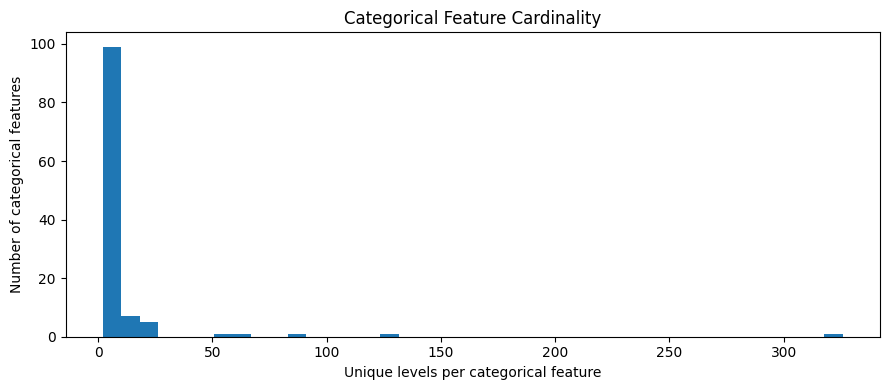

In [5]:
continuous_summary = train_df[continuous_cols].describe().T
continuous_summary["skewness"] = train_df[continuous_cols].skew()
display(continuous_summary)

categorical_cardinality = (
    train_df[categorical_cols]
    .nunique(dropna=False)
    .sort_values(ascending=False)
    .rename("unique_levels")
    .to_frame()
)
display(categorical_cardinality.head(20))

plt.figure(figsize=(9, 4))
plt.hist(categorical_cardinality["unique_levels"], bins=40)
plt.title("Categorical Feature Cardinality")
plt.xlabel("Unique levels per categorical feature")
plt.ylabel("Number of categorical features")
plt.tight_layout()
plt.show()

### Categorical Feature Characteristics

The dataset contains 116 categorical features, including several with many levels. Because the labels are nominal, simple ordinal encoding can impose an artificial numeric order.

Two approaches are compared:

- **Ordinal encoding:** assigns each category a numeric code and handles unseen validation or test categories with a reserved value.
- **Out-of-fold smoothed target encoding:** replaces each category with a smoothed estimate learned from other training rows. Within the transformed-target pipeline, these mappings are learned from `log1p(loss)`, not raw validation or test outcomes.

The out-of-fold procedure prevents a training row from using its own target value in its encoded features, reducing target-leakage risk.


## 6. Validation Design and Evaluation Metrics

The full training file is divided into:

- **80% model-development data**, used for preprocessing and fitting; and
- **20% holdout validation data**, used for model comparison and error analysis.

The split is stratified by approximate loss quantiles so that the loss distribution is represented in both portions. Every model uses the same split.

### Evaluation Measures

| Measure | Interpretation |
|---|---|
| **MAE** | Average absolute prediction error in dollars; primary selection metric |
| **Median absolute error** | Typical absolute error for the middle claim |
| **RMSE** | Penalizes large errors more heavily than MAE |
| **R²** | Fraction of holdout variation explained relative to a mean prediction |
| **Precision, recall, and lift** | Severe-claim capture when review capacity is limited |
| **Spearman correlation** | Quality of the predicted severity ranking |

Because the same holdout is used to compare candidate models and report the selected result, some **model-selection optimism** may remain. The bootstrap interval reported later describes sampling uncertainty for the selected validation predictions; it does not include split uncertainty, temporal drift, or model-selection uncertainty.


In [6]:
if FAST_MODE:
    modeling_df = train_df.sample(
        n=min(FAST_N, len(train_df)),
        random_state=RANDOM_STATE,
    ).copy()
    print(f"FAST_MODE is on: using {len(modeling_df):,} rows.")
else:
    modeling_df = train_df.copy()
    print(f"FAST_MODE is off: using all {len(modeling_df):,} rows.")


def make_regression_strata(y, q=10):
    """Create approximate quantile strata for a continuous target."""
    try:
        strata = pd.qcut(
            pd.Series(y),
            q=q,
            labels=False,
            duplicates="drop",
        )
    except ValueError:
        return None

    return strata if strata.nunique() >= 2 else None


X = modeling_df[feature_cols].copy()
y = modeling_df[TARGET].copy()
strata = make_regression_strata(y)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=strata,
)

assert set(X_train.index).isdisjoint(X_valid.index)
assert len(X_train) + len(X_valid) == len(X)
assert TARGET not in X_train.columns
assert ID_COL not in X_train.columns

print("Training split:", X_train.shape)
print("Validation split:", X_valid.shape)

FAST_MODE is off: using all 188,318 rows.
Training split: (150654, 130)
Validation split: (37664, 130)


In [7]:
def regression_metrics(y_true, y_pred):
    """Return regression metrics on the original nonnegative dollar scale."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "Median_AE": median_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


def evaluate_model(name, model, X_fit, y_fit, X_eval, y_eval, notes=""):
    """Fit and evaluate one model on the fixed validation split."""
    fitted_model = clone(model)
    fitted_model.fit(X_fit, y_fit)

    prediction = np.clip(fitted_model.predict(X_eval), 0, None)
    metrics = regression_metrics(y_eval, prediction)

    result = {
        "model": name,
        "validation_MAE": metrics["MAE"],
        "validation_RMSE": metrics["RMSE"],
        "validation_Median_AE": metrics["Median_AE"],
        "validation_R2": metrics["R2"],
        "notes": notes,
    }
    return fitted_model, prediction, result


def bootstrap_mae_interval(
    y_true,
    y_pred,
    n_boot=500,
    confidence=0.95,
):
    """Estimate a claim-level bootstrap interval for validation MAE."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rng = np.random.default_rng(RANDOM_STATE)
    estimates = np.empty(n_boot, dtype=float)

    for bootstrap_index in range(n_boot):
        row_index = rng.integers(0, len(y_true), size=len(y_true))
        estimates[bootstrap_index] = mean_absolute_error(
            y_true[row_index],
            y_pred[row_index],
        )

    alpha = (1.0 - confidence) / 2.0
    return np.quantile(estimates, [alpha, 1.0 - alpha])

## 7. Baseline Models

Two constant-prediction baselines establish the minimum standard for usefulness:

- the training-set mean loss; and
- the training-set median loss.

The median is often competitive under MAE when the target is strongly right-skewed. A machine-learning model should materially improve on the stronger baseline before its added complexity is justified.


In [8]:
baseline_rows = []

baseline_values = {
    "Mean-loss baseline": ("mean", float(y_train.mean())),
    "Median-loss baseline": ("median", float(y_train.median())),
}

for baseline_name, (summary_statistic, constant_prediction) in baseline_values.items():
    prediction = np.full(
        len(y_valid),
        constant_prediction,
        dtype=float,
    )
    metrics = regression_metrics(y_valid, prediction)

    baseline_rows.append(
        {
            "model": baseline_name,
            "validation_MAE": metrics["MAE"],
            "validation_RMSE": metrics["RMSE"],
            "validation_Median_AE": metrics["Median_AE"],
            "validation_R2": metrics["R2"],
            "notes": (
                f"Predicts the training-set {summary_statistic} "
                "for every validation claim."
            ),
        }
    )

baseline_results = (
    pd.DataFrame(baseline_rows)
    .sort_values("validation_MAE")
    .reset_index(drop=True)
)

baseline_display = baseline_results.copy()
currency_columns = [
    "validation_MAE",
    "validation_RMSE",
    "validation_Median_AE",
]
for column in currency_columns:
    baseline_display[column] = baseline_display[column].map(
        lambda value: f"${value:,.0f}"
    )
baseline_display["validation_R2"] = baseline_display["validation_R2"].map(
    lambda value: f"{value:.3f}"
)
display(baseline_display)


,model,validation_MAE,validation_RMSE,validation_Median_AE,validation_R2,notes
0,Median-loss baseline,"$1,796","$2,949","$1,114",-0.105,Predicts the training-set median for every validation claim.
1,Mean-loss baseline,"$1,954","$2,806","$1,630",-0.000,Predicts the training-set mean for every validation claim.


## 8. Preprocessing and Feature Encoding

Two preprocessing pipelines are evaluated with ridge regression and a log-transformed target.

### Pipeline A: Ordinal Encoding

Categorical levels are converted to numeric codes, continuous features are standardized, and ridge regression is fitted to `log1p(loss)`.

### Pipeline B: Out-of-Fold Target Encoding

Continuous features are retained, categorical levels are replaced by smoothed out-of-fold transformed-target estimates, all resulting features are standardized, and the same regression family is fitted.

Using the same regression family makes the comparison primarily about the value of the encoding strategy.


In [9]:
linear_preprocess = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            categorical_cols,
        ),
        (
            "continuous",
            StandardScaler(),
            continuous_cols,
        ),
    ],
    remainder="drop",
)


class OutOfFoldSmoothedTargetEncoder(BaseEstimator, TransformerMixin):
    """Leakage-controlled out-of-fold smoothed target encoding."""

    def __init__(
        self,
        categorical_cols,
        continuous_cols,
        smoothing=25.0,
        n_splits=5,
        random_state=42,
    ):
        self.categorical_cols = categorical_cols
        self.continuous_cols = continuous_cols
        self.smoothing = smoothing
        self.n_splits = n_splits
        self.random_state = random_state

    def _as_frame(self, X):
        if isinstance(X, pd.DataFrame):
            frame = X.copy()
        else:
            columns = getattr(self, "feature_names_in_", None)
            frame = pd.DataFrame(X, columns=columns)

        required_columns = (
            list(self.continuous_cols)
            + list(self.categorical_cols)
        )
        missing_columns = [
            column
            for column in required_columns
            if column not in frame.columns
        ]
        if missing_columns:
            raise ValueError(
                "Target encoder is missing columns: "
                f"{missing_columns[:10]}"
            )

        return frame

    def _learn_maps(self, X, y):
        X = self._as_frame(X)
        y = np.asarray(y, dtype=float)

        if len(X) != len(y):
            raise ValueError("X and y lengths do not match.")

        # The enclosing transformed-target regressor passes log1p(loss).
        global_mean = float(np.mean(y))
        mappings = {}

        for column in self.categorical_cols:
            temporary = pd.DataFrame(
                {
                    "category": X[column].to_numpy(),
                    "target": y,
                },
                index=X.index,
            )
            statistics = temporary.groupby(
                "category",
                dropna=False,
            )["target"].agg(["count", "mean"])

            smoothed_values = (
                statistics["count"] * statistics["mean"]
                + self.smoothing * global_mean
            ) / (statistics["count"] + self.smoothing)

            mappings[column] = smoothed_values.to_dict()

        return global_mean, mappings

    def _transform_with(self, X, global_mean, mappings):
        X = self._as_frame(X)
        transformed_parts = []

        if self.continuous_cols:
            continuous = (
                X[list(self.continuous_cols)]
                .apply(pd.to_numeric, errors="raise")
                .to_numpy(dtype=float)
            )
            if not np.isfinite(continuous).all():
                raise ValueError(
                    "Continuous features contain non-finite values."
                )
            transformed_parts.append(continuous)

        if self.categorical_cols:
            encoded_columns = []
            for column in self.categorical_cols:
                encoded = (
                    X[column]
                    .map(mappings[column])
                    .fillna(global_mean)
                    .to_numpy(dtype=float)
                    .reshape(-1, 1)
                )
                encoded_columns.append(encoded)

            transformed_parts.append(np.hstack(encoded_columns))

        if not transformed_parts:
            raise ValueError("No columns were supplied to the target encoder.")

        return np.hstack(transformed_parts)

    def fit(self, X, y):
        X = self._as_frame(X)
        self.feature_names_in_ = np.asarray(
            X.columns,
            dtype=object,
        )
        self.global_mean_, self.maps_ = self._learn_maps(X, y)
        return self

    def fit_transform(self, X, y, **fit_params):
        X = self._as_frame(X)
        y = np.asarray(y, dtype=float)

        n_samples = len(X)
        n_splits = min(self.n_splits, n_samples)

        if n_splits < 2:
            return self.fit(X, y).transform(X)

        encoded = np.empty(
            (
                n_samples,
                len(self.continuous_cols)
                + len(self.categorical_cols),
            ),
            dtype=float,
        )

        splitter = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=self.random_state,
        )

        for fold_train_index, fold_holdout_index in splitter.split(X):
            fold_X = X.iloc[fold_train_index]
            fold_y = y[fold_train_index]

            fold_global_mean, fold_mappings = self._learn_maps(
                fold_X,
                fold_y,
            )

            encoded[fold_holdout_index] = self._transform_with(
                X.iloc[fold_holdout_index],
                fold_global_mean,
                fold_mappings,
            )

        self.fit(X, y)
        return encoded

    def transform(self, X):
        return self._transform_with(
            X,
            self.global_mean_,
            self.maps_,
        )

    def get_feature_names_out(self, input_features=None):
        feature_names = [
            f"continuous__{column}"
            for column in self.continuous_cols
        ]
        feature_names += [
            f"target_encoded__{column}"
            for column in self.categorical_cols
        ]
        return np.asarray(feature_names, dtype=object)


## 9. Model Development and Comparison

Both machine-learning pipelines are fitted on the model-development split and evaluated on the same holdout claims. The selected model is the one with the lowest validation MAE.

The goal is not an exhaustive algorithm search. It is a reproducible comparison that is strong enough to answer the practicum question while keeping the preprocessing and leakage controls transparent.


In [10]:
models = {
    "Ridge regression with ordinal encoding (log target)": (
        TransformedTargetRegressor(
            regressor=Pipeline(
                steps=[
                    ("preprocess", linear_preprocess),
                    ("model", Ridge(alpha=20.0)),
                ]
            ),
            func=np.log1p,
            inverse_func=np.expm1,
        )
    ),
    "Ridge regression with OOF target encoding (log target)": (
        TransformedTargetRegressor(
            regressor=Pipeline(
                steps=[
                    (
                        "target_encode",
                        OutOfFoldSmoothedTargetEncoder(
                            categorical_cols=categorical_cols,
                            continuous_cols=continuous_cols,
                            smoothing=50.0,
                            n_splits=3,
                            random_state=RANDOM_STATE,
                        ),
                    ),
                    ("scale", StandardScaler()),
                    ("model", Ridge(alpha=30.0)),
                ]
            ),
            func=np.log1p,
            inverse_func=np.expm1,
        )
    ),
}

fitted_models = {}
validation_predictions = {}
model_rows = list(baseline_rows)

for model_name, model in models.items():
    print(f"Fitting: {model_name}")

    fitted_model, prediction, result = evaluate_model(
        model_name,
        model,
        X_train,
        y_train,
        X_valid,
        y_valid,
    )

    fitted_models[model_name] = fitted_model
    validation_predictions[model_name] = prediction
    model_rows.append(result)

results_df = (
    pd.DataFrame(model_rows)
    .sort_values("validation_MAE")
    .reset_index(drop=True)
)

best_baseline_row = baseline_results.iloc[0]

results_df["MAE_improvement_vs_best_baseline_pct"] = (
    100.0
    * (
        best_baseline_row["validation_MAE"]
        - results_df["validation_MAE"]
    )
    / best_baseline_row["validation_MAE"]
)

results_display = results_df.copy()
for column in ["validation_MAE", "validation_RMSE", "validation_Median_AE"]:
    results_display[column] = results_display[column].map(lambda value: f"${value:,.0f}")
results_display["validation_R2"] = results_display["validation_R2"].map(lambda value: f"{value:.3f}")
results_display["MAE_improvement_vs_best_baseline_pct"] = results_display[
    "MAE_improvement_vs_best_baseline_pct"
].map(lambda value: f"{value:.1f}%")
display(results_display)


Fitting: Ridge regression with ordinal encoding (log target)
Fitting: Ridge regression with OOF target encoding (log target)


,model,validation_MAE,validation_RMSE,validation_Median_AE,validation_R2,notes,MAE_improvement_vs_best_baseline_pct
0,Ridge regression with OOF target encoding (log target),"$1,254","$2,142",$720,0.417,,30.2%
1,Ridge regression with ordinal encoding (log target),"$1,277","$2,184",$742,0.394,,28.9%
2,Median-loss baseline,"$1,796","$2,949","$1,114",-0.105,Predicts the training-set median for every validation claim.,0.0%
3,Mean-loss baseline,"$1,954","$2,806","$1,630",-0.000,Predicts the training-set mean for every validation claim.,-8.8%


## 10. Retransformation Bias and Duan Smearing

Models trained on `log1p(loss)` may systematically understate expected dollars after applying `expm1`. A Duan-smearing experiment tests whether a multiplicative correction improves the dollar-scale predictions.

The correction factor is estimated from a calibration subset drawn only from the model-development data. Validation targets are not used to fit the model or estimate the factor.

The corrected and uncorrected predictions are compared on average error, signed error, overall calibration, upper-tail calibration, severe-claim underprediction, and conditional shortfall. The correction is adopted only if the executed evidence supports it.


In [11]:
machine_learning_results = results_df[
    results_df["model"].isin(validation_predictions)
].copy()

best_model_name = (
    machine_learning_results
    .sort_values("validation_MAE")
    .iloc[0]["model"]
)

best_fitted_model = fitted_models[best_model_name]
uncorrected_validation_pred = validation_predictions[best_model_name]


def smearing_diagnostics(
    y_true,
    prediction,
    very_high_threshold,
):
    """Summarize average accuracy and upper-tail calibration."""
    y_true = np.asarray(y_true, dtype=float)
    prediction = np.clip(
        np.asarray(prediction, dtype=float),
        0,
        None,
    )

    signed_error = y_true - prediction
    very_high_mask = y_true >= very_high_threshold
    very_high_signed_error = signed_error[very_high_mask]
    underprediction_mask = very_high_signed_error > 0

    metrics = regression_metrics(y_true, prediction)

    conditional_shortfall = (
        float(very_high_signed_error[underprediction_mask].mean())
        if underprediction_mask.any()
        else 0.0
    )

    return {
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "Median_AE": metrics["Median_AE"],
        "R2": metrics["R2"],
        "mean_signed_error": float(signed_error.mean()),
        "overall_actual_to_predicted_ratio": (
            float(y_true.mean() / prediction.mean())
        ),
        "very_high_actual_to_predicted_ratio": (
            float(
                y_true[very_high_mask].mean()
                / prediction[very_high_mask].mean()
            )
        ),
        "very_high_underprediction_rate": (
            float(underprediction_mask.mean())
        ),
        "very_high_conditional_shortfall": conditional_shortfall,
    }


# Estimate the correction on rows held out from a training-only fit.
smearing_strata = make_regression_strata(y_train)
(
    X_smear_fit,
    X_smear_calibration,
    y_smear_fit,
    y_smear_calibration,
) = train_test_split(
    X_train,
    y_train,
    test_size=SMEARING_CALIBRATION_FRACTION,
    random_state=RANDOM_STATE + 1,
    stratify=smearing_strata,
)

assert set(X_smear_fit.index).isdisjoint(X_smear_calibration.index)
assert set(X_smear_calibration.index).isdisjoint(X_valid.index)

smearing_model = clone(models[best_model_name])
smearing_model.fit(X_smear_fit, y_smear_fit)

if not isinstance(smearing_model, TransformedTargetRegressor):
    raise TypeError(
        "The smearing experiment requires a "
        "TransformedTargetRegressor."
    )

calibration_log_prediction = (
    smearing_model.regressor_.predict(X_smear_calibration)
)
log_residual = (
    np.log1p(y_smear_calibration.to_numpy(dtype=float))
    - calibration_log_prediction
)
smearing_factor = float(np.mean(np.exp(log_residual)))

validation_log_prediction = (
    best_fitted_model.regressor_.predict(X_valid)
)

reconstructed_uncorrected_prediction = np.clip(
    np.expm1(validation_log_prediction),
    0,
    None,
)

if not np.allclose(
    reconstructed_uncorrected_prediction,
    uncorrected_validation_pred,
    rtol=1e-7,
    atol=1e-7,
):
    raise AssertionError(
        "Reconstructed validation predictions do not match "
        "the model's inverse-transformed predictions."
    )

smearing_corrected_validation_pred = np.clip(
    np.exp(validation_log_prediction) * smearing_factor - 1.0,
    0,
    None,
)

very_high_threshold = float(y_train.quantile(0.95))

smearing_rows = []
for version_name, prediction in {
    "Uncorrected inverse transformation": (
        uncorrected_validation_pred
    ),
    "Duan-smearing corrected": (
        smearing_corrected_validation_pred
    ),
}.items():
    diagnostics = smearing_diagnostics(
        y_valid,
        prediction,
        very_high_threshold,
    )
    diagnostics["prediction_version"] = version_name
    smearing_rows.append(diagnostics)

smearing_comparison = (
    pd.DataFrame(smearing_rows)
    .set_index("prediction_version")
)

smearing_comparison["MAE_change_vs_uncorrected_pct"] = (
    100.0
    * (
        smearing_comparison["MAE"]
        / smearing_comparison.loc[
            "Uncorrected inverse transformation",
            "MAE",
        ]
        - 1.0
    )
)

display(
    pd.DataFrame(
        {
            "measure": [
                "Estimated Duan smearing factor",
                "Training rows reserved for calibration",
            ],
            "value": [
                f"{smearing_factor:.4f}",
                f"{len(X_smear_calibration):,} "
                f"({SMEARING_CALIBRATION_FRACTION:.0%} of X_train)",
            ],
        }
    )
)
display(smearing_comparison)

corrected_mae = smearing_comparison.loc[
    "Duan-smearing corrected",
    "MAE",
]
uncorrected_mae = smearing_comparison.loc[
    "Uncorrected inverse transformation",
    "MAE",
]

if corrected_mae < uncorrected_mae:
    prediction_version = "Duan-smearing corrected"
    best_validation_pred = smearing_corrected_validation_pred
    smearing_was_adopted = True
    smearing_interpretation = (
        "The smearing correction improved validation MAE and was "
        "carried forward into the remaining analysis."
    )
else:
    prediction_version = "Uncorrected inverse transformation"
    best_validation_pred = uncorrected_validation_pred
    smearing_was_adopted = False
    smearing_interpretation = (
        "The smearing correction did not improve validation MAE, so "
        "the uncorrected prediction remains the primary result. The "
        "comparison is still useful because it shows the trade-off "
        "between dollar calibration and average prediction error."
    )

display(Markdown(f"**Decision:** {smearing_interpretation}"))

,measure,value
0,Estimated Duan smearing factor,1.1689
1,Training rows reserved for calibration,"30,131 (20% of X_train)"


,MAE,RMSE,Median_AE,R2,mean_signed_error,overall_actual_to_predicted_ratio,very_high_actual_to_predicted_ratio,very_high_underprediction_rate,very_high_conditional_shortfall,MAE_change_vs_uncorrected_pct
prediction_version,,,,,,,,,,
Uncorrected inverse transformation,1254.378711,2142.392380,719.562462,0.417109,355.896675,1.133436,1.554968,0.854011,5707.276765,0.000000
Duan-smearing corrected,1316.001269,2216.947808,825.217550,0.375834,-94.715979,0.969621,1.330277,0.779679,5168.979542,4.912596


**Decision:** The smearing correction did not improve validation MAE, so the uncorrected prediction remains the primary result. The comparison is still useful because it shows the trade-off between dollar calibration and average prediction error.

## 11. Selected Model Performance

The selected model is evaluated on **37,664 holdout claims** that were not used for fitting. Results are reported on the original dollar scale.

A claim-level bootstrap provides a 95% interval for validation MAE. This interval reflects sampling variation within the fixed holdout predictions; it does not account for alternative splits, model selection, future drift, or operational changes.


In [12]:
selected_metrics = regression_metrics(
    y_valid,
    best_validation_pred,
)

mae_ci_low, mae_ci_high = bootstrap_mae_interval(
    y_valid,
    best_validation_pred,
    n_boot=BOOTSTRAP_SAMPLES,
)

mae_improvement_vs_best_baseline = (
    100.0
    * (
        best_baseline_row["validation_MAE"]
        - selected_metrics["MAE"]
    )
    / best_baseline_row["validation_MAE"]
)

selected_result_summary = pd.DataFrame(
    {
        "measure": [
            "Selected model",
            "Prediction version",
            "Validation MAE",
            "Bootstrap 95% MAE interval",
            "Validation RMSE",
            "Validation median absolute error",
            "Validation R²",
            "MAE improvement vs strongest baseline",
        ],
        "value": [
            best_model_name,
            prediction_version,
            f"${selected_metrics['MAE']:,.0f}",
            f"${mae_ci_low:,.0f} to ${mae_ci_high:,.0f}",
            f"${selected_metrics['RMSE']:,.0f}",
            f"${selected_metrics['Median_AE']:,.0f}",
            f"{selected_metrics['R2']:.3f}",
            f"{mae_improvement_vs_best_baseline:.1f}%",
        ],
    }
)
display(selected_result_summary)

,measure,value
0,Selected model,Ridge regression with OOF target encoding (log target)
1,Prediction version,Uncorrected inverse transformation
2,Validation MAE,"$1,254"
3,Bootstrap 95% MAE interval,"$1,237 to $1,270"
4,Validation RMSE,"$2,142"
5,Validation median absolute error,$720
6,Validation R²,0.417
7,MAE improvement vs strongest baseline,30.2%


In [13]:
selected_interpretation = f"""
### Interpretation of the Selected Model

The selected model was evaluated on **{len(y_valid):,} holdout claims**. Its validation MAE was **${selected_metrics['MAE']:,.0f} per claim**, a **{mae_improvement_vs_best_baseline:.1f}% improvement** over the strongest constant baseline.

The median absolute error was **${selected_metrics['Median_AE']:,.0f}**, while RMSE was **${selected_metrics['RMSE']:,.0f}**. The gap between these measures indicates that a subset of large errors remains important.

The model explains useful variation in loss, but the holdout result is not sufficient by itself to support automatic claims decisions. The following sections examine upper-tail error, severe-claim capture, ranking quality, and calibration.
"""
display(Markdown(selected_interpretation))



### Interpretation of the Selected Model

The selected model was evaluated on **37,664 holdout claims**. Its validation MAE was **$1,254 per claim**, a **30.2% improvement** over the strongest constant baseline.

The median absolute error was **$720**, while RMSE was **$2,142**. The gap between these measures indicates that a subset of large errors remains important.

The model explains useful variation in loss, but the holdout result is not sufficient by itself to support automatic claims decisions. The following sections examine upper-tail error, severe-claim capture, ranking quality, and calibration.


## 12. Error Analysis by Claim Severity

Average performance can conceal risk in the most expensive claims. The validation set is therefore evaluated by actual-loss decile and by severity groups defined from training-set thresholds.

The **Very High** group contains validation claims above the training-set 95th-percentile loss threshold. For each group, the analysis reports:

- MAE and median absolute error;
- mean signed error;
- underprediction rate;
- average shortfall across all claims; and
- average shortfall conditional on underprediction.

A positive signed error means actual loss exceeded predicted loss.


In [14]:
error_df = pd.DataFrame(
    {
        "actual_loss": np.asarray(y_valid, dtype=float),
        "predicted_loss": np.clip(
            np.asarray(best_validation_pred, dtype=float),
            0,
            None,
        ),
    },
    index=y_valid.index,
)

error_df["signed_error"] = (
    error_df["actual_loss"]
    - error_df["predicted_loss"]
)
error_df["absolute_error"] = error_df["signed_error"].abs()
error_df["underpredicted"] = error_df["signed_error"] > 0
error_df["shortfall"] = error_df["signed_error"].clip(lower=0)
error_df["conditional_shortfall"] = error_df["signed_error"].where(
    error_df["underpredicted"]
)

error_df["actual_loss_decile"] = (
    pd.qcut(
        error_df["actual_loss"],
        q=10,
        labels=False,
        duplicates="drop",
    )
    + 1
)

decile_summary = (
    error_df.groupby(
        "actual_loss_decile",
        observed=True,
    )
    .agg(
        claims=("actual_loss", "size"),
        actual_mean=("actual_loss", "mean"),
        predicted_mean=("predicted_loss", "mean"),
        mae=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median"),
        mean_signed_error=("signed_error", "mean"),
        underprediction_rate=("underpredicted", "mean"),
        average_shortfall_all_claims=("shortfall", "mean"),
        conditional_shortfall_when_underpredicted=(
            "conditional_shortfall",
            "mean",
        ),
    )
    .reset_index()
)
display(decile_summary)

q50, q90, q95 = y_train.quantile([0.50, 0.90, 0.95])
severity_labels = ["Low", "Medium", "High", "Very High"]

error_df["actual_severity_group"] = pd.cut(
    error_df["actual_loss"],
    bins=[-np.inf, q50, q90, q95, np.inf],
    labels=severity_labels,
    include_lowest=True,
)

severity_summary = (
    error_df.groupby(
        "actual_severity_group",
        observed=False,
    )
    .agg(
        claims=("actual_loss", "size"),
        actual_mean=("actual_loss", "mean"),
        predicted_mean=("predicted_loss", "mean"),
        mae=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median"),
        mean_signed_error=("signed_error", "mean"),
        underprediction_rate=("underpredicted", "mean"),
        average_shortfall_all_claims=("shortfall", "mean"),
        conditional_shortfall_when_underpredicted=(
            "conditional_shortfall",
            "mean",
        ),
    )
    .reindex(severity_labels)
)
display(severity_summary)

,actual_loss_decile,claims,actual_mean,predicted_mean,mae,median_absolute_error,mean_signed_error,underprediction_rate,average_shortfall_all_claims,conditional_shortfall_when_underpredicted
0,1,3767,586.272506,1374.445526,788.641889,656.670405,-788.173020,0.003982,0.234434,58.874272
1,2,3766,913.334572,1537.488734,637.703891,493.894785,-624.154161,0.065321,6.774865,103.716022
2,3,3766,1204.545244,1665.908209,532.435282,356.657407,-461.362965,0.210834,35.536159,168.550596
3,4,3767,1528.000000,1837.031755,520.094319,336.342593,-309.031755,0.385984,105.531282,273.408761
4,5,3766,1902.605106,1998.341384,558.565046,432.760472,-95.736278,0.552841,231.414384,418.591052
5,6,3766,2367.449150,2265.439301,729.679981,625.795018,102.009849,0.641795,415.844915,647.940402
6,7,3767,2992.321696,2596.216072,1016.579078,946.938096,396.105624,0.734537,706.342351,961.616060
7,8,3766,3875.988463,3077.151981,1433.184319,1369.249772,798.836481,0.782793,1116.010400,1425.676787
8,9,3766,5303.174203,3954.570551,2067.778896,2038.957363,1348.603653,0.795539,1708.191274,2147.212396
9,10,3767,9556.389559,6364.803536,4258.708447,3760.403111,3191.586024,0.844704,3725.147235,4410.003028


,claims,actual_mean,predicted_mean,mae,median_absolute_error,mean_signed_error,underprediction_rate,average_shortfall_all_claims,conditional_shortfall_when_underpredicted
actual_severity_group,,,,,,,,,
Low,18832,1226.933451,1682.634954,607.493064,459.869272,-455.701503,0.243787,75.895780,311.319830
Medium,15066,3634.874330,2973.507911,1311.737927,1066.156571,661.366419,0.738683,986.552173,1335.555310
High,1896,7279.770132,5116.016254,3023.504240,3014.888751,2163.753878,0.835443,2593.629059,3104.495389
Very High,1870,11866.350037,7631.248833,5513.049591,5114.090675,4235.101204,0.854011,4874.075398,5707.276765


In [15]:
very_high_validation = severity_summary.loc["Very High"]
tail_message = f"""
### Very High-Severity Claims

For validation claims above the training-set 95th-percentile loss threshold, MAE was **${very_high_validation['mae']:,.0f}**.

The model underpredicted **{very_high_validation['underprediction_rate']:.1%}** of these claims. Conditional on underprediction, the average shortfall was **${very_high_validation['conditional_shortfall_when_underpredicted']:,.0f}**.

This upper-tail behavior is not consistent with using the model prediction as an automatic reserve amount. It does, however, support using high scores to trigger additional review.
"""
display(Markdown(tail_message))



### Very High-Severity Claims

For validation claims above the training-set 95th-percentile loss threshold, MAE was **$5,513**.

The model underpredicted **85.4%** of these claims. Conditional on underprediction, the average shortfall was **$5,707**.

This upper-tail behavior is not consistent with using the model prediction as an automatic reserve amount. It does, however, support using high scores to trigger additional review.


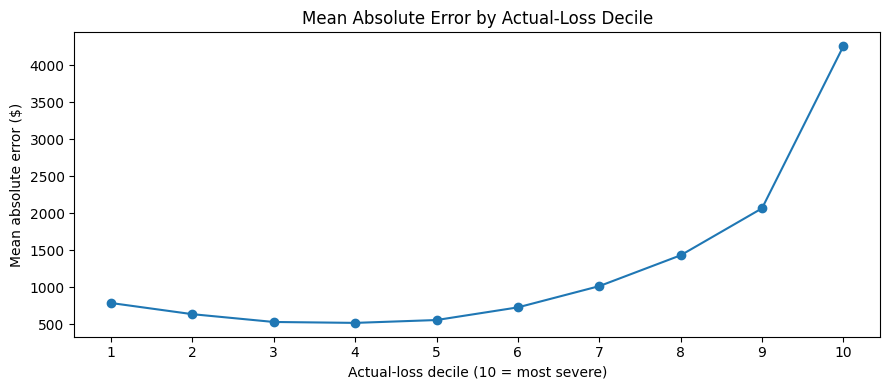

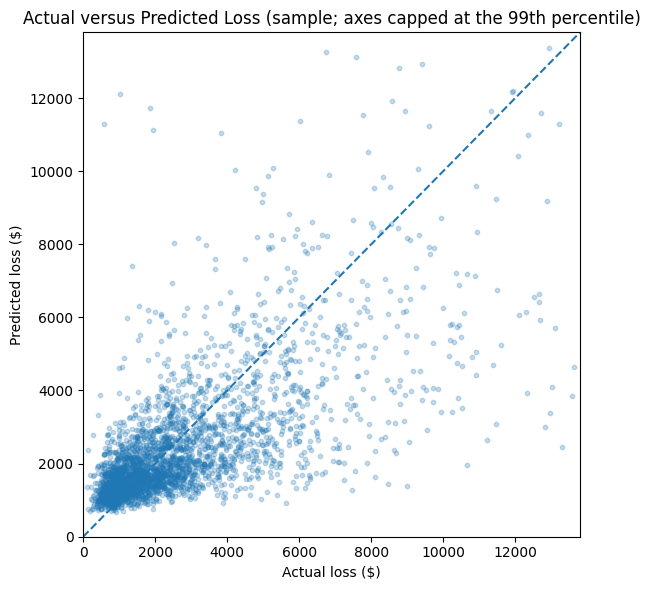

In [16]:
plt.figure(figsize=(9, 4))
plt.plot(
    decile_summary["actual_loss_decile"],
    decile_summary["mae"],
    marker="o",
)
plt.title("Mean Absolute Error by Actual-Loss Decile")
plt.xlabel("Actual-loss decile (10 = most severe)")
plt.ylabel("Mean absolute error ($)")
plt.xticks(decile_summary["actual_loss_decile"])
plt.tight_layout()
plt.show()

plot_sample = error_df.sample(
    n=min(3_000, len(error_df)),
    random_state=RANDOM_STATE,
)
axis_cap = error_df["actual_loss"].quantile(0.99)

plt.figure(figsize=(6, 6))
plt.scatter(
    plot_sample["actual_loss"],
    plot_sample["predicted_loss"],
    alpha=0.25,
    s=10,
)
plt.plot(
    [0, axis_cap],
    [0, axis_cap],
    linestyle="--",
)
plt.xlim(0, axis_cap)
plt.ylim(0, axis_cap)
plt.title(
    "Actual versus Predicted Loss "
    "(sample; axes capped at the 99th percentile)"
)
plt.xlabel("Actual loss ($)")
plt.ylabel("Predicted loss ($)")
plt.tight_layout()
plt.show()

## 13. Severe-Claim Capture at Fixed Review Capacity

Operational teams cannot review every claim. This section asks:

> If claims are ranked by predicted loss, how many truly severe claims are captured when only 5%, 10%, 20%, or 30% of claims can receive additional review?

A **severe claim** is defined using the training-set 90th-percentile loss threshold. Applying a training-derived threshold avoids using validation outcomes to define the decision rule.

The analysis reports the number captured and missed, precision, recall, and lift relative to random review.


,review_capacity,claims_reviewed,actual_severe_claims,severe_claims_captured,severe_claims_missed,precision,recall,lift_vs_random_review
0,0.05,1884,3766,1284,2482,0.681529,0.340945,6.816010
1,0.10,3767,3766,2090,1676,0.554818,0.554965,5.548771
2,0.20,7533,3766,2965,801,0.393601,0.787307,3.936433
3,0.30,11300,3766,3344,422,0.295929,0.887945,2.959606


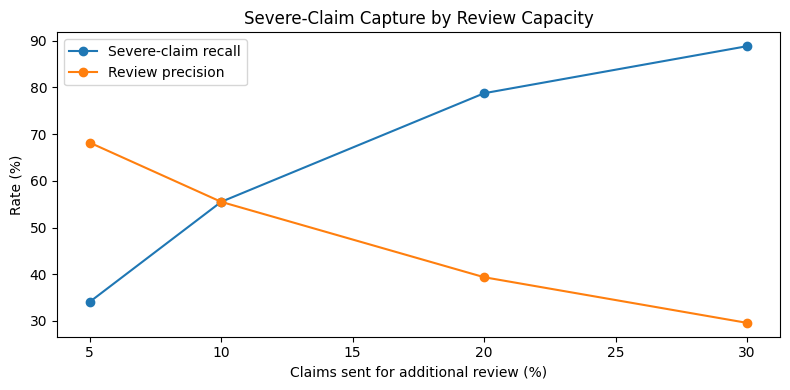

In [17]:
def review_capacity_table(
    actual_loss,
    predicted_loss,
    severe_threshold,
    capacities=(0.05, 0.10, 0.20, 0.30),
):
    """Evaluate severe-claim capture under fixed review capacity."""
    actual_loss = np.asarray(actual_loss, dtype=float)
    predicted_loss = np.asarray(predicted_loss, dtype=float)

    actual_severe = actual_loss >= severe_threshold
    severe_count = int(actual_severe.sum())
    severe_base_rate = float(actual_severe.mean())

    ranked_index = np.argsort(-predicted_loss)
    rows = []

    for capacity in capacities:
        claims_reviewed = max(
            1,
            int(np.ceil(capacity * len(actual_loss))),
        )
        reviewed_index = ranked_index[:claims_reviewed]
        severe_captured = int(
            actual_severe[reviewed_index].sum()
        )

        precision = severe_captured / claims_reviewed
        recall = (
            severe_captured / severe_count
            if severe_count
            else np.nan
        )
        lift = (
            precision / severe_base_rate
            if severe_base_rate
            else np.nan
        )

        rows.append(
            {
                "review_capacity": capacity,
                "claims_reviewed": claims_reviewed,
                "actual_severe_claims": severe_count,
                "severe_claims_captured": severe_captured,
                "severe_claims_missed": (
                    severe_count - severe_captured
                ),
                "precision": precision,
                "recall": recall,
                "lift_vs_random_review": lift,
            }
        )

    return pd.DataFrame(rows)


severe_90_threshold = float(y_train.quantile(0.90))

capacity_results = review_capacity_table(
    error_df["actual_loss"],
    error_df["predicted_loss"],
    severe_threshold=severe_90_threshold,
    capacities=REVIEW_CAPACITIES,
)
display(capacity_results)

plt.figure(figsize=(8, 4))
plt.plot(
    100 * capacity_results["review_capacity"],
    100 * capacity_results["recall"],
    marker="o",
    label="Severe-claim recall",
)
plt.plot(
    100 * capacity_results["review_capacity"],
    100 * capacity_results["precision"],
    marker="o",
    label="Review precision",
)
plt.title("Severe-Claim Capture by Review Capacity")
plt.xlabel("Claims sent for additional review (%)")
plt.ylabel("Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

### Week 5 chart update

For this week's pod lab, I cleaned up the chart above for a non-technical audience. I kept the same review-capacity results, removed the extra precision line, and highlighted the 10% review point so the main finding is easier to see.

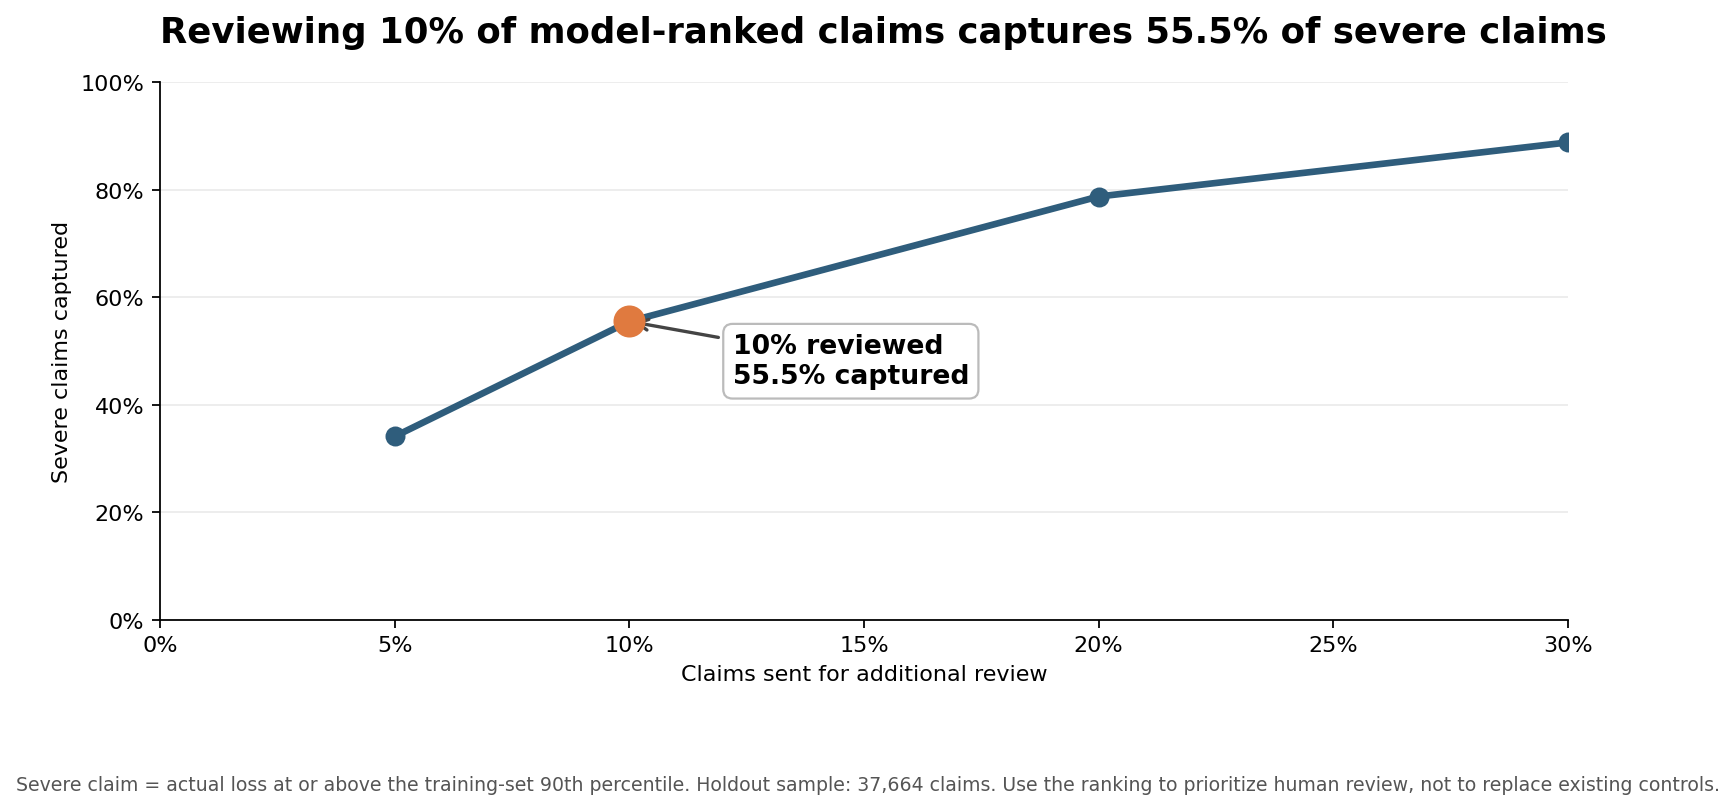

In [ ]:
# Week 5: cleaner version for an executive audience
# I kept one message and highlighted the 10% review point.

plot_data = capacity_results.sort_values("review_capacity").copy()

review_percent = 100 * plot_data["review_capacity"]
capture_percent = 100 * plot_data["recall"]

ten_percent_row = plot_data.loc[
    np.isclose(plot_data["review_capacity"], 0.10)
].iloc[0]

ten_percent_review = 100 * ten_percent_row["review_capacity"]
ten_percent_capture = 100 * ten_percent_row["recall"]

fig, ax = plt.subplots(figsize=(10, 5.6))

ax.plot(
    review_percent,
    capture_percent,
    marker="o",
    linewidth=3,
    markersize=8,
    color="#2F5D7C",
)

ax.scatter(
    ten_percent_review,
    ten_percent_capture,
    s=180,
    color="#E07A3F",
    zorder=4,
)

ax.set_title(
    "Reviewing 10% of model-ranked claims captures 55.5% of severe claims",
    loc="left",
    fontsize=16,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel("Claims sent for additional review")
ax.set_ylabel("Severe claims captured")

ax.set_xlim(0, 30)
ax.set_ylim(0, 100)
ax.set_xticks([0, 5, 10, 15, 20, 25, 30])
ax.set_yticks([0, 20, 40, 60, 80, 100])

ax.xaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(xmax=100, decimals=0)
)
ax.yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(xmax=100, decimals=0)
)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.annotate(
    f"10% reviewed\n{ten_percent_capture:.1f}% captured",
    xy=(ten_percent_review, ten_percent_capture),
    xytext=(12.2, 44),
    fontsize=12,
    fontweight="bold",
    arrowprops={
        "arrowstyle": "->",
        "lw": 1.5,
        "color": "#444444",
    },
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "#BBBBBB",
    },
)

fig.text(
    0.01,
    0.01,
    "Severe claim = actual loss at or above the training-set 90th percentile. "
    f"Holdout sample: {len(error_df):,} claims. "
    "Use the ranking to support human review, not replace it.",
    fontsize=8.5,
    color="#555555",
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.80,
    bottom=0.20,
)

plt.show()


In [18]:
capacity_10 = capacity_results.loc[
    np.isclose(capacity_results["review_capacity"], 0.10)
].iloc[0]

capacity_message = f"""
### Results at 10% Review Capacity

The model selected **{int(capacity_10['claims_reviewed']):,} claims** for additional review.

The queue captured **{int(capacity_10['severe_claims_captured']):,} of {int(capacity_10['actual_severe_claims']):,} severe claims**, equivalent to **{capacity_10['recall']:.1%} recall**. Review precision was **{capacity_10['precision']:.1%}**, and lift relative to random review was **{capacity_10['lift_vs_random_review']:.2f}×**.

The queue still missed **{int(capacity_10['severe_claims_missed']):,} severe claims**. This supports model-guided prioritization only when combined with existing rules and human judgment.
"""
display(Markdown(capacity_message))



### Results at 10% Review Capacity

The model selected **3,767 claims** for additional review.

The queue captured **2,090 of 3,766 severe claims**, equivalent to **55.5% recall**. Review precision was **55.5%**, and lift relative to random review was **5.55×**.

The queue still missed **1,676 severe claims**. This supports model-guided prioritization only when combined with existing rules and human judgment.


## 14. Ranking Quality and Calibration

Two properties are evaluated separately:

1. **Ranking quality:** whether higher predictions generally correspond to higher actual losses.
2. **Dollar calibration:** whether predicted amounts match observed amounts within risk bands.

A model may be useful for prioritization even when its exact dollar estimates are imperfect. The analysis uses Spearman rank correlation, observed loss by predicted-risk band, and actual-to-predicted ratios to distinguish these properties.


,claims,actual_mean,actual_median,predicted_mean,mae,underprediction_rate,actual_to_predicted_ratio,actual_loss_lift_vs_overall
predicted_review_band,,,,,,,,
Low,18832,1643.158944,1342.830,1428.929471,706.840771,0.474246,1.149923,0.543539
Medium,11299,3120.342437,2681.310,2541.319019,1332.424719,0.547571,1.227844,1.032175
High,5649,5442.484015,4882.750,4611.838931,2111.698060,0.545406,1.180111,1.800313
Very High,1884,8978.681274,8175.615,9968.371691,3688.771305,0.372611,0.900717,2.970048


Spearman rank correlation: 0.707


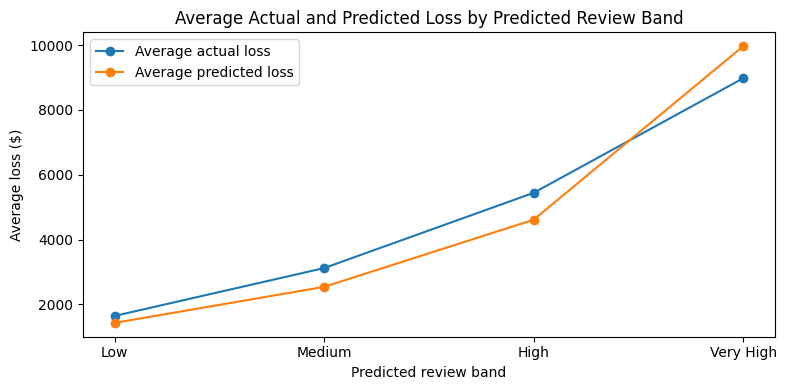

In [19]:
predicted_quantiles = error_df["predicted_loss"].quantile(
    [0.50, 0.80, 0.95]
)
pred_q50, pred_q80, pred_q95 = predicted_quantiles
predicted_band_labels = ["Low", "Medium", "High", "Very High"]

error_df["predicted_review_band"] = pd.cut(
    error_df["predicted_loss"],
    bins=[
        -np.inf,
        pred_q50,
        pred_q80,
        pred_q95,
        np.inf,
    ],
    labels=predicted_band_labels,
    include_lowest=True,
)

overall_actual_mean = error_df["actual_loss"].mean()

ranking_calibration_summary = (
    error_df.groupby(
        "predicted_review_band",
        observed=False,
    )
    .agg(
        claims=("actual_loss", "size"),
        actual_mean=("actual_loss", "mean"),
        actual_median=("actual_loss", "median"),
        predicted_mean=("predicted_loss", "mean"),
        mae=("absolute_error", "mean"),
        underprediction_rate=("underpredicted", "mean"),
    )
    .reindex(predicted_band_labels)
)

ranking_calibration_summary[
    "actual_to_predicted_ratio"
] = (
    ranking_calibration_summary["actual_mean"]
    / ranking_calibration_summary["predicted_mean"]
)

ranking_calibration_summary[
    "actual_loss_lift_vs_overall"
] = (
    ranking_calibration_summary["actual_mean"]
    / overall_actual_mean
)

spearman_rank_correlation = error_df[
    ["actual_loss", "predicted_loss"]
].corr(method="spearman").iloc[0, 1]

display(ranking_calibration_summary)
print(
    "Spearman rank correlation:",
    f"{spearman_rank_correlation:.3f}",
)

plt.figure(figsize=(8, 4))
plt.plot(
    predicted_band_labels,
    ranking_calibration_summary["actual_mean"],
    marker="o",
    label="Average actual loss",
)
plt.plot(
    predicted_band_labels,
    ranking_calibration_summary["predicted_mean"],
    marker="o",
    label="Average predicted loss",
)
plt.title("Average Actual and Predicted Loss by Predicted Review Band")
plt.xlabel("Predicted review band")
plt.ylabel("Average loss ($)")
plt.legend()
plt.tight_layout()
plt.show()

### Ranking Assessment

Observed average loss rises consistently across the predicted review bands, and the Spearman correlation shows a strong monotonic relationship between predicted and actual severity.

The highest predicted band successfully identifies a much more expensive group of claims. Calibration is not uniform across bands, so the ranking evidence is stronger than the evidence for using predictions as exact reserve amounts.


## 15. Business Use Assessment

The same model result does not justify every claims decision.

| Potential use | Evidence-based assessment |
|---|---|
| Predict claim loss better than a constant baseline | **Supported on the fixed holdout** |
| Prioritize claims for reserve review | **Promising as decision support** |
| Automatically set reserve amounts | **Not supported** |
| Add a financial-severity signal to triage | **Promising as one input** |
| Assign claims to specific adjusters | **Not testable with these data** |

The most defensible use is a human-reviewed priority queue for claims with higher predicted severity.


In [20]:
decision_support_matrix = pd.DataFrame(
    {
        "decision": [
            "Predict final claim loss",
            "Prioritize reserve review",
            "Set reserve amounts automatically",
            "Prioritize claim triage",
            "Assign a claim to a specific adjuster",
        ],
        "conclusion": [
            "Supported on this holdout relative to simple baselines",
            "Promising as a decision-support signal",
            "Not supported",
            "Promising as one financial-risk signal",
            "Not supported",
        ],
        "reason": [
            (
                "The selected model is compared with mean and "
                "median baselines using dollar-scale metrics."
            ),
            (
                "Higher model ranks concentrate more claims above "
                "the training-set severe-loss threshold."
            ),
            (
                "Tail error, calibration limits, and missing reserve "
                "and coverage data make automatic amounts unsafe."
            ),
            (
                "Financial severity can justify earlier attention, "
                "but it does not capture every form of urgency."
            ),
            (
                "Predicted cost does not measure adjuster fit, and "
                "skills, workload, fairness, and outcomes are absent."
            ),
        ],
    }
)
display(decision_support_matrix)

,decision,conclusion,reason
0,Predict final claim loss,Supported on this holdout relative to simple baselines,The selected model is compared with mean and median baselines using dollar-scale metrics.
1,Prioritize reserve review,Promising as a decision-support signal,Higher model ranks concentrate more claims above the training-set severe-loss threshold.
2,Set reserve amounts automatically,Not supported,"Tail error, calibration limits, and missing reserve and coverage data make automatic amounts uns..."
3,Prioritize claim triage,Promising as one financial-risk signal,"Financial severity can justify earlier attention, but it does not capture every form of urgency."
4,Assign a claim to a specific adjuster,Not supported,"Predicted cost does not measure adjuster fit, and skills, workload, fairness, and outcomes are a..."


### Recommended Use

Use the model to identify claims that warrant earlier or more detailed review. Do not treat the prediction as the final reserve and do not infer adjuster fit from predicted cost alone.

This recommendation uses the model where the evidence is strongest—ranking financial severity—while protecting against its main weakness: underprediction in the upper tail.


### Proposed Human-in-the-Loop Workflow

A cautious operational workflow would:

1. score each newly reported claim using verified day-one inputs;
2. combine the score with existing coverage, injury, litigation, fraud, and policy-limit rules;
3. route the highest-priority claims to human reserve review;
4. allow reviewers to override the score and record the reason;
5. monitor severe-claim misses, calibration, drift, fairness, and workload effects; and
6. suspend or revise the model if performance falls outside agreed thresholds.

This workflow is a proposed design, not an operational result demonstrated by the current dataset.


## 16. Final Model Training and Test Predictions

After model selection, the chosen pipeline is refitted on the complete training dataset and used to predict every row in the supplied test file.

The output checks confirm:

- one prediction per test claim;
- exact ID alignment with the sample submission;
- no missing or duplicate IDs;
- finite, nonnegative predicted losses; and
- the required two-column output structure.

Because the test file does not contain `loss`, it cannot provide an additional accuracy estimate.


In [21]:
final_model = clone(models[best_model_name])

final_training_data = (
    modeling_df.copy()
    if FAST_MODE
    else train_df.copy()
)

if FAST_MODE:
    print(
        "FAST_MODE is on: final predictions use the "
        "modeling sample."
    )
else:
    print(
        "FAST_MODE is off: final model uses the full "
        "training dataset."
    )

final_model.fit(
    final_training_data[feature_cols],
    final_training_data[TARGET],
)

if smearing_was_adopted:
    test_log_prediction = (
        final_model.regressor_.predict(
            test_df[feature_cols]
        )
    )
    test_prediction = np.clip(
        np.exp(test_log_prediction) * smearing_factor - 1.0,
        0,
        None,
    )
else:
    test_prediction = np.clip(
        final_model.predict(test_df[feature_cols]),
        0,
        None,
    )

if len(test_prediction) != len(sample_submission):
    raise ValueError(
        "Prediction count does not match the sample submission."
    )

submission = sample_submission[[ID_COL]].copy()
submission[TARGET] = test_prediction

if submission.isna().any().any():
    raise AssertionError("The submission contains missing values.")
if submission[ID_COL].duplicated().any():
    raise AssertionError("The submission contains duplicate IDs.")
if (submission[TARGET] < 0).any():
    raise AssertionError("The submission contains negative predictions.")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = OUTPUT_DIR / OUTPUT_FILENAME
submission.to_csv(output_path, index=False)

print("Final prediction file:", output_path.name)
display(submission.head())


FAST_MODE is off: final model uses the full training dataset.
Final prediction file: Allstate_Claim_Severity_Predictions.csv


,id,loss
0,4,1481.012850
1,6,1875.584274
2,9,12774.427069
3,12,4537.682354
4,15,746.053929


## 17. Reproducibility and Submission Checks

The final verification confirms that the exact supplied datasets were used, the full training data supported the reported analysis, validation and test predictions are complete, and the prediction file has the required IDs and valid nonnegative values.

These checks support reproducibility of the notebook run. They do not remove the dataset's semantic and temporal limitations.


In [22]:
completion_checks = pd.DataFrame(
    {
        "objective_check": [
            "Exact supplied training file used",
            "Exact supplied test file used",
            "Exact supplied sample-submission file used",
            "Full training data used for reported results",
            "Validation prediction count matches validation rows",
            "All validation predictions are finite",
            "Submission row count matches sample submission",
            "Submission IDs exactly match sample submission",
            "All submission predictions are finite",
            "All submission predictions are nonnegative",
        ],
        "status": [
            train_sha256 == EXPECTED_DATASETS["training"]["sha256"],
            test_sha256 == EXPECTED_DATASETS["test"]["sha256"],
            submission_sha256 == EXPECTED_DATASETS["sample submission"]["sha256"],
            FAST_MODE is False and len(modeling_df) == len(train_df),
            len(best_validation_pred) == len(y_valid),
            bool(np.isfinite(np.asarray(best_validation_pred)).all()),
            len(submission) == len(sample_submission),
            bool(submission[ID_COL].equals(sample_submission[ID_COL])),
            bool(np.isfinite(submission[TARGET].to_numpy()).all()),
            bool((submission[TARGET] >= 0).all()),
        ],
    }
)

display(completion_checks)

if not completion_checks["status"].all():
    failed_checks = completion_checks.loc[
        ~completion_checks["status"], "objective_check"
    ].tolist()
    raise AssertionError(
        "One or more final checks failed: "
        + "; ".join(failed_checks)
    )

print("All reproducibility and submission checks passed.")
print("Final prediction file:", output_path.name)


,objective_check,status
0,Exact supplied training file used,True
1,Exact supplied test file used,True
2,Exact supplied sample-submission file used,True
3,Full training data used for reported results,True
4,Validation prediction count matches validation rows,True
5,All validation predictions are finite,True
6,Submission row count matches sample submission,True
7,Submission IDs exactly match sample submission,True
8,All submission predictions are finite,True
9,All submission predictions are nonnegative,True


All reproducibility and submission checks passed.
Final prediction file: Allstate_Claim_Severity_Predictions.csv


## 18. Conclusion

The final conclusion synthesizes the holdout accuracy, severe-claim error, ranking performance, review-capacity results, retransformation test, and dataset limitations to answer the research question directly.


In [23]:
top_10_capacity_row = capacity_results.loc[
    np.isclose(capacity_results["review_capacity"], 0.10)
].iloc[0]
very_high_row = severity_summary.loc["Very High"]

uncorrected_row = smearing_comparison.loc[
    "Uncorrected inverse transformation"
]
corrected_row = smearing_comparison.loc[
    "Duan-smearing corrected"
]
smearing_mae_change = corrected_row[
    "MAE_change_vs_uncorrected_pct"
]

final_answer = f"""
### Direct Answer

**Machine learning materially improves claim-severity prediction and provides useful ranking information for reserve-review and claim-triage prioritization. The evidence does not support automatic reserve setting or specific adjuster assignment.**

Using the **{prediction_version.lower()}**, the selected model—**{best_model_name}**—was evaluated on **{len(y_valid):,} holdout claims**. It achieved an MAE of **${selected_metrics['MAE']:,.0f}** (bootstrap 95% interval: **${mae_ci_low:,.0f} to ${mae_ci_high:,.0f}**), an RMSE of **${selected_metrics['RMSE']:,.0f}**, a median absolute error of **${selected_metrics['Median_AE']:,.0f}**, and an R² of **{selected_metrics['R2']:.3f}**. Its MAE was **{mae_improvement_vs_best_baseline:.1f}% lower** than the strongest constant baseline.

The model also produced a useful severity ranking. Spearman rank correlation between predicted and actual loss was **{spearman_rank_correlation:.3f}**. At a **10% review capacity**, the model captured **{top_10_capacity_row['recall']:.1%}** of claims above the training-set 90th-percentile severity threshold, with **{top_10_capacity_row['precision']:.1%} precision** and **{top_10_capacity_row['lift_vs_random_review']:.2f}× lift** over random review. It still missed **{int(top_10_capacity_row['severe_claims_missed']):,} severe claims**, so the queue cannot replace existing controls.

Upper-tail performance remains the main weakness. For claims above the training-set 95th-percentile threshold, MAE was **${very_high_row['mae']:,.0f}** and the model underpredicted **{very_high_row['underprediction_rate']:.1%}** of claims. When underprediction occurred, the average shortfall was **${very_high_row['conditional_shortfall_when_underpredicted']:,.0f}**. These results make the raw prediction unsafe as an automatic reserve amount.

The Duan-smearing correction improved overall and upper-tail calibration, reducing the Very High underprediction rate from **{uncorrected_row['very_high_underprediction_rate']:.1%}** to **{corrected_row['very_high_underprediction_rate']:.1%}**. However, it increased validation MAE by **{smearing_mae_change:.1f}%** and worsened RMSE and R², so it was not adopted as the primary prediction.

### What the Results Demonstrate

The notebook demonstrates that the anonymized features contain meaningful predictive information and that the model can support a human review queue by concentrating higher-loss claims near the top.

### What the Results Do Not Demonstrate

The analysis does not prove that all predictors are available on day one, that performance will hold over time, that reserve outcomes improve in practice, or that a particular adjuster is the best match for a claim. Adjuster skills, workload, assignment history, reserve history, policy limits, and operational outcomes are absent.

Because candidate models were selected using the same holdout on which final performance is reported, some model-selection optimism may remain. The bootstrap interval does not account for that uncertainty or for temporal drift.

### Final Recommendation

Use the model as a **decision-support prioritization tool** for reserve review and financial-severity triage. Do not use it by itself to set reserve amounts or assign claims to adjusters.

The single most important next step is an **out-of-time validation on newer claims using verified day-one features**. Operational testing should not proceed until that validation confirms stable accuracy, ranking, calibration, and severe-claim capture.

The completed test predictions are saved as **`{output_path.name}`**.
"""

display(Markdown(final_answer))



### Direct Answer

**Machine learning materially improves claim-severity prediction and provides useful ranking information for reserve-review and claim-triage prioritization. The evidence does not support automatic reserve setting or specific adjuster assignment.**

Using the **uncorrected inverse transformation**, the selected model—**Ridge regression with OOF target encoding (log target)**—was evaluated on **37,664 holdout claims**. It achieved an MAE of **$1,254** (bootstrap 95% interval: **$1,237 to $1,270**), an RMSE of **$2,142**, a median absolute error of **$720**, and an R² of **0.417**. Its MAE was **30.2% lower** than the strongest constant baseline.

The model also produced a useful severity ranking. Spearman rank correlation between predicted and actual loss was **0.707**. At a **10% review capacity**, the model captured **55.5%** of claims above the training-set 90th-percentile severity threshold, with **55.5% precision** and **5.55× lift** over random review. It still missed **1,676 severe claims**, so the queue cannot replace existing controls.

Upper-tail performance remains the main weakness. For claims above the training-set 95th-percentile threshold, MAE was **$5,513** and the model underpredicted **85.4%** of claims. When underprediction occurred, the average shortfall was **$5,707**. These results make the raw prediction unsafe as an automatic reserve amount.

The Duan-smearing correction improved overall and upper-tail calibration, reducing the Very High underprediction rate from **85.4%** to **78.0%**. However, it increased validation MAE by **4.9%** and worsened RMSE and R², so it was not adopted as the primary prediction.

### What the Results Demonstrate

The notebook demonstrates that the anonymized features contain meaningful predictive information and that the model can support a human review queue by concentrating higher-loss claims near the top.

### What the Results Do Not Demonstrate

The analysis does not prove that all predictors are available on day one, that performance will hold over time, that reserve outcomes improve in practice, or that a particular adjuster is the best match for a claim. Adjuster skills, workload, assignment history, reserve history, policy limits, and operational outcomes are absent.

Because candidate models were selected using the same holdout on which final performance is reported, some model-selection optimism may remain. The bootstrap interval does not account for that uncertainty or for temporal drift.

### Final Recommendation

Use the model as a **decision-support prioritization tool** for reserve review and financial-severity triage. Do not use it by itself to set reserve amounts or assign claims to adjusters.

The single most important next step is an **out-of-time validation on newer claims using verified day-one features**. Operational testing should not proceed until that validation confirms stable accuracy, ranking, calibration, and severe-claim capture.

The completed test predictions are saved as **`Allstate_Claim_Severity_Predictions.csv`**.
